#  SARIMAX Forecasting

## Appliance Energy Forecasting

This notebook develops and evaluates a Seasonal AutoRegressive Integrated Moving Average model with exogenous variables (SARIMAX) for hourly appliance energy use.

The analysis includes:

- model specification based on hourly daily seasonality;
- AIC-based parameter selection;
- selected exogenous weather and time-based covariates;
- residual diagnostics;
- 24-hour forecasting with confidence intervals;
- rolling-origin evaluation over the final 14-day test period;
- comparison against the strongest benchmark model.

A daily seasonal period of 24 observations is used for the hourly dataset.

In [1]:
from pathlib import Path
from itertools import product

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
PROJECT_ROOT = Path(
    r"C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FORECAST_DIR = PROJECT_ROOT / "outputs" / "forecasts"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
MODEL_DIR = PROJECT_ROOT / "outputs" / "model_objects"

for directory in [
    FIGURE_DIR,
    FORECAST_DIR,
    METRICS_DIR,
    MODEL_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

DATA_FILE = (
    PROCESSED_DIR /
    "appliance_energy_hourly.csv"
)

print("Data file exists:", DATA_FILE.exists())

Data file exists: True


In [3]:
hourly_data = pd.read_csv(
    DATA_FILE,
    index_col="date",
    parse_dates=True
)

hourly_data = hourly_data.sort_index()

TARGET = "Appliances"

target = hourly_data[TARGET].copy()

print("Dataset shape:", hourly_data.shape)
print("Target observations:", len(target))
print(
    "Date range:",
    target.index.min(),
    "to",
    target.index.max()
)

Dataset shape: (3290, 28)
Target observations: 3290
Date range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00


In [4]:
# Forecast configuration

DAILY_PERIOD = 24
WEEKLY_PERIOD = 168

FORECAST_HORIZON = 24

TEST_DAYS = 14
TEST_STEPS = TEST_DAYS * 24

INITIAL_TRAIN_SIZE = (
    len(target) - TEST_STEPS
)

print(
    "Forecast horizon:",
    FORECAST_HORIZON
)

print(
    "Test observations:",
    TEST_STEPS
)

print(
    "Initial training observations:",
    INITIAL_TRAIN_SIZE
)

Forecast horizon: 24
Test observations: 336
Initial training observations: 2954


In [5]:
# Train/test split

train = target.iloc[
    :INITIAL_TRAIN_SIZE
].copy()

test = target.iloc[
    INITIAL_TRAIN_SIZE:
].copy()

print("Training period:")
print(
    train.index.min(),
    "to",
    train.index.max()
)

print("\nTest period:")
print(
    test.index.min(),
    "to",
    test.index.max()
)

print(
    "\nTrain-test overlap:",
    len(
        train.index.intersection(
            test.index
        )
    )
)

Training period:
2016-01-11 17:00:00 to 2016-05-13 18:00:00

Test period:
2016-05-13 19:00:00 to 2016-05-27 18:00:00

Train-test overlap: 0


##  Exogenous Covariates

SARIMAX can incorporate additional variables that may help explain short-term appliance energy use.

The model considers:

- outdoor temperature;
- outdoor relative humidity;
- wind speed;
- visibility;
- dew point;
- hour-of-day cyclical features;
- day-of-week cyclical features.

Time-based variables are known in advance at the forecast origin. Future realised weather observations, however, may not be available operationally and therefore represent a conditional-forecast setting when taken directly from the test data.



In [6]:
# Time features

def add_time_features(df):
    """
    Add cyclical hour-of-day and day-of-week features.
    """

    out = df.copy()

    out["hour"] = out.index.hour
    out["dayofweek"] = out.index.dayofweek

    out["hour_sin"] = np.sin(
        2 * np.pi * out["hour"] / 24
    )

    out["hour_cos"] = np.cos(
        2 * np.pi * out["hour"] / 24
    )

    out["dow_sin"] = np.sin(
        2 * np.pi * out["dayofweek"] / 7
    )

    out["dow_cos"] = np.cos(
        2 * np.pi * out["dayofweek"] / 7
    )

    return out

In [7]:
#  Prepare SARIMAX covariates

sarimax_data = add_time_features(
    hourly_data
)

candidate_exog_cols = [
    "T_out",
    "RH_out",
    "Windspeed",
    "Visibility",
    "Tdewpoint",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

exog_cols = [
    col
    for col in candidate_exog_cols
    if col in sarimax_data.columns
]

print("SARIMAX exogenous variables:")

for col in exog_cols:
    print("-", col)

SARIMAX exogenous variables:
- T_out
- RH_out
- Windspeed
- Visibility
- Tdewpoint
- hour_sin
- hour_cos
- dow_sin
- dow_cos


In [8]:
# Prepare X train/test

X = sarimax_data[
    exog_cols
].copy()

X_train = X.iloc[
    :INITIAL_TRAIN_SIZE
].copy()

X_test = X.iloc[
    INITIAL_TRAIN_SIZE:
].copy()

print(
    "X_train shape:",
    X_train.shape
)

print(
    "X_test shape:",
    X_test.shape
)

print(
    "Missing exogenous values:",
    X.isna().sum().sum()
)

X_train shape: (2954, 9)
X_test shape: (336, 9)
Missing exogenous values: 0


##  AIC-Based Non-Seasonal Parameter Search

The non-seasonal SARIMAX parameters are selected using the Akaike Information Criterion (AIC).

The required search space is:

- p = 0 to 6
- d = 0 to 2
- q = 0 to 6

A lower AIC indicates a preferred balance between model fit and complexity.

Because the hourly series exhibits strong daily seasonality, a seasonal period of 24 observations is retained during the search.

In [9]:
# AIC search function

def sarimax_aic_search(
    y_train,
    X_train=None,
    p_values=range(0, 7),
    d_values=range(0, 3),
    q_values=range(0, 7),
    seasonal_order=(1, 0, 1, 24)
):
    """
    Search non-seasonal SARIMAX orders using AIC.
    """

    results = []

    combinations = list(
        product(
            p_values,
            d_values,
            q_values
        )
    )

    print(
        "Total combinations:",
        len(combinations)
    )

    for i, (p, d, q) in enumerate(
        combinations,
        start=1
    ):

        try:

            model = SARIMAX(
                y_train,
                exog=X_train,
                order=(p, d, q),
                seasonal_order=seasonal_order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit(
                disp=False,
                maxiter=100
            )

            results.append({
                "p": p,
                "d": d,
                "q": q,
                "AIC": fitted.aic,
                "BIC": fitted.bic
            })

        except Exception as error:

            results.append({
                "p": p,
                "d": d,
                "q": q,
                "AIC": np.nan,
                "BIC": np.nan
            })

        if i % 10 == 0:
            print(
                f"Completed {i}/{len(combinations)}"
            )

    results_df = (
        pd.DataFrame(results)
        .dropna(
            subset=["AIC"]
        )
        .sort_values(
            "AIC"
        )
        .reset_index(
            drop=True
        )
    )

    return results_df

In [10]:
# Test search

test_search_results = (
    sarimax_aic_search(
        y_train=train,
        X_train=X_train,
        p_values=range(0, 2),
        d_values=range(0, 2),
        q_values=range(0, 2),
        seasonal_order=(
            1,
            0,
            1,
            24
        )
    )
)

test_search_results.head()

Total combinations: 8


,p,d,q,AIC,BIC
0,1,0,1,32503.090074,32592.821197
1,1,0,0,32655.271905,32739.025734
2,1,1,1,32665.310256,32755.036256
3,0,1,1,32740.529102,32824.273368
4,1,1,0,32917.337705,33001.086753


In [11]:
# Full required p,d,q search

nonseasonal_search_results = (
    sarimax_aic_search(
        y_train=train,
        X_train=X_train,
        p_values=range(0, 7),
        d_values=range(0, 3),
        q_values=range(0, 7),
        seasonal_order=(
            1,
            0,
            1,
            24
        )
    )
)

nonseasonal_search_results.head(10)

Total combinations: 147
Completed 10/147
Completed 20/147
Completed 30/147
Completed 40/147
Completed 50/147
Completed 60/147
Completed 70/147
Completed 80/147
Completed 90/147
Completed 100/147
Completed 110/147
Completed 120/147
Completed 130/147
Completed 140/147


,p,d,q,AIC,BIC
0,1,0,6,32429.454467,32549.061782
1,2,0,6,32430.163541,32555.751222
2,4,0,6,32435.148860,32572.697272
3,5,0,6,32437.247013,32580.775791
4,6,0,0,32437.271252,32550.904701
5,6,0,6,32437.992197,32587.501342
6,6,0,1,32438.444321,32558.058477
7,2,0,5,32438.579151,32558.193308
8,0,0,6,32439.477986,32553.104936
9,1,0,5,32439.660876,32553.294325


In [15]:
print("Kernel is responsive")

Kernel is responsive


In [16]:
nonseasonal_search_results.to_csv(
    METRICS_DIR / "sarimax_nonseasonal_search_results.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [17]:
best_order

(1, 0, 6)

## Select the Best Non-Seasonal Order

A systematic grid search was performed over the required non-seasonal parameter space:

- p = 0–6
- d = 0–2
- q = 0–6

The optimal non-seasonal order was selected using the minimum Akaike Information Criterion (AIC). The resulting order is used as the fixed non-seasonal component during the seasonal parameter search.

In [18]:
# Save non-seasonal search results

nonseasonal_search_results.to_csv(
    METRICS_DIR / "sarimax_nonseasonal_search_results.csv",
    index=False
)

print("Non-seasonal search results saved.")

Non-seasonal search results saved.


In [20]:
# Load saved non-seasonal search results if required

NONSEASONAL_RESULTS_FILE = (
    METRICS_DIR / "sarimax_nonseasonal_search_results.csv"
)

if "nonseasonal_search_results" not in globals():
    nonseasonal_search_results = pd.read_csv(
        NONSEASONAL_RESULTS_FILE
    )
    print("Loaded saved non-seasonal search results.")
else:
    print("Using non-seasonal search results already in memory.")

nonseasonal_search_results.head()

Using non-seasonal search results already in memory.


,p,d,q,AIC,BIC
0,1,0,6,32429.454467,32549.061782
1,2,0,6,32430.163541,32555.751222
2,4,0,6,32435.148860,32572.697272
3,5,0,6,32437.247013,32580.775791
4,6,0,0,32437.271252,32550.904701


In [19]:
# Extract Best Order

best_nonseasonal = nonseasonal_search_results.iloc[0]

best_order = (
    int(best_nonseasonal["p"]),
    int(best_nonseasonal["d"]),
    int(best_nonseasonal["q"])
)

print("Best non-seasonal order:", best_order)
print("Best AIC:", round(best_nonseasonal["AIC"], 3))

Best non-seasonal order: (1, 0, 6)
Best AIC: 32429.454


## Seasonal Parameter Search

The assignment requires modelling daily seasonality.

The seasonal period is fixed at:

- s = 24 hours

The non-seasonal order identified during the previous search is held constant while searching over the seasonal parameters:

- P = 0–2
- D = 0–1
- Q = 0–2

The optimal seasonal order is selected using AIC.

In [21]:
# Seasonal Search

seasonal_search_results = seasonal_aic_search(
    y_train=train,
    order=best_order,
    X_train=X_train,
    P_values=range(0, 2),
    D_values=range(0, 2),
    Q_values=range(0, 2),
    seasonal_period=24
)

seasonal_search_results.head(10)

Total seasonal combinations: 8


,P,D,Q,Seasonal_Period,AIC,BIC
0,1,1,1,24,32323.314093,32442.756515
1,0,1,1,24,32349.883786,32463.354087
2,1,0,1,24,32429.454467,32549.061782
3,0,0,1,24,32563.341555,32676.968505
4,1,0,0,24,32628.168033,32741.833944
5,0,0,0,24,32864.916400,32972.710174
6,1,1,0,24,33273.009659,33386.519244
7,0,1,0,24,34205.103311,34312.749895


In [26]:
# Save Seasonal Search

SEASONAL_RESULTS_FILE = (
    METRICS_DIR /
    "sarimax_seasonal_search_results.csv"
)

seasonal_search_results.to_csv(
    SEASONAL_RESULTS_FILE,
    index=False
)

print("Seasonal search results saved successfully.")

Seasonal search results saved successfully.


In [23]:
# Select Best Seasonal Order

best_seasonal = seasonal_search_results.iloc[0]

best_seasonal_order = (
    int(best_seasonal["P"]),
    int(best_seasonal["D"]),
    int(best_seasonal["Q"]),
    24
)

print("Best seasonal order:", best_seasonal_order)
print("Best seasonal AIC:", round(best_seasonal["AIC"], 3))

Best seasonal order: (1, 1, 1, 24)
Best seasonal AIC: 32323.314


In [27]:
print(SEASONAL_RESULTS_FILE.exists())

True


## Final SARIMAX Model

The AIC-based search selected the non-seasonal order `(1, 0, 6)` and the seasonal order `(1, 1, 1, 24)`.

The final SARIMAX specification is therefore:

`SARIMAX(1,0,6)(1,1,1,24)`

The model incorporates daily seasonality together with selected exogenous weather and time-based covariates.

In [28]:
# Fit final SARIMAX model

final_sarimax_model = SARIMAX(
    train,
    exog=X_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarimax_fit = final_sarimax_model.fit(
    disp=False,
    maxiter=100
)

print("Final SARIMAX model fitted successfully.")
print("Order:", best_order)
print("Seasonal order:", best_seasonal_order)
print("AIC:", round(final_sarimax_fit.aic, 3))
print("BIC:", round(final_sarimax_fit.bic, 3))

Final SARIMAX model fitted successfully.
Order: (1, 0, 6)
Seasonal order: (1, 1, 1, 24)
AIC: 32323.314
BIC: 32442.757


In [29]:
print(final_sarimax_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                           Appliances   No. Observations:                 2954
Model:             SARIMAX(1, 0, 6)x(1, 1, [1], 24)   Log Likelihood              -16141.657
Date:                              Thu, 13 Aug 2026   AIC                          32323.314
Time:                                      06:37:21   BIC                          32442.757
Sample:                                  01-11-2016   HQIC                         32366.352
                                       - 05-13-2016                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -2.6689      0.812     -3.287      0.001      -4.260      -1.077
T_out         -6.62

In [30]:
# Extract the residuals

sarimax_residuals = (
    final_sarimax_fit
    .resid
    .dropna()
)

sarimax_residuals.describe()

count    2954.000000
mean        9.383484
std        73.441919
min      -249.280845
25%       -21.235749
50%         2.037351
75%        19.847040
max       552.696342
dtype: float64

In [32]:
sarimax_residuals.describe().to_csv(
    METRICS_DIR /
    "sarimax_residual_summary.csv"
)

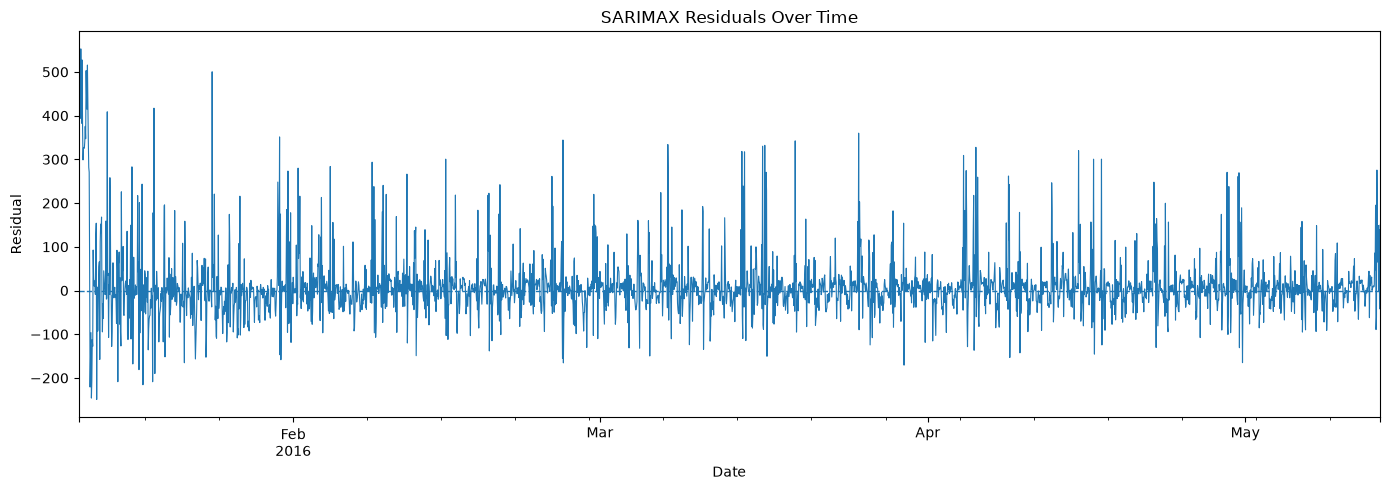

In [33]:
# Residual time-series plot

fig, ax = plt.subplots(figsize=(14, 5))

sarimax_residuals.plot(
    ax=ax,
    linewidth=0.8
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "SARIMAX Residuals Over Time"
)

ax.set_xlabel("Date")
ax.set_ylabel("Residual")

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "23_sarimax_residuals_time.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

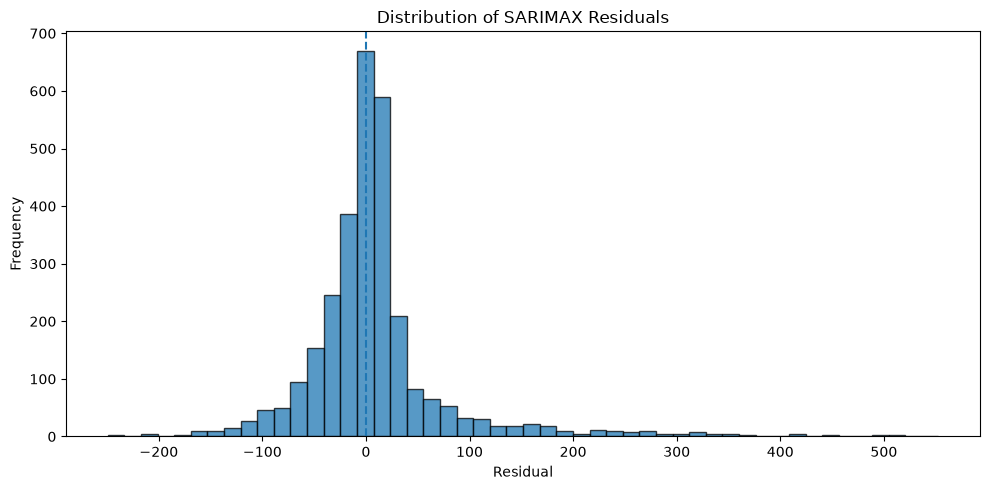

In [34]:
# Residual distribution.

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    sarimax_residuals,
    bins=50,
    edgecolor="black",
    alpha=0.75
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_title(
    "Distribution of SARIMAX Residuals"
)

ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "24_sarimax_residual_distribution.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

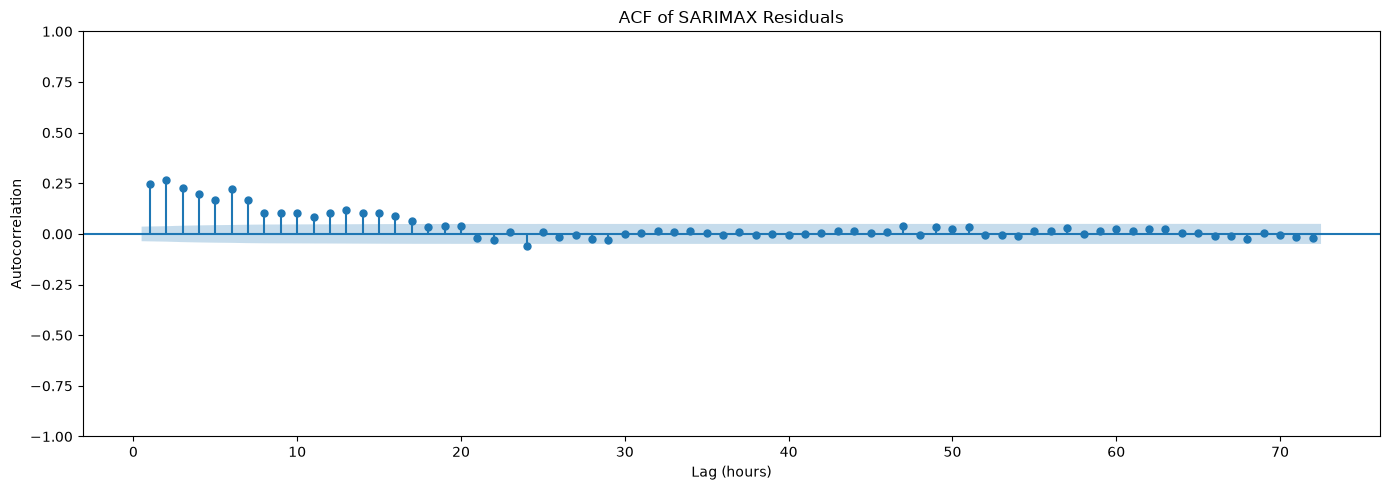

In [35]:
# Residual ACF

fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    sarimax_residuals,
    lags=72,
    ax=ax,
    zero=False
)

ax.set_title(
    "ACF of SARIMAX Residuals"
)

ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation")

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "25_sarimax_residual_acf.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
# Ljung–Box test

ljung_box_results = acorr_ljungbox(
    sarimax_residuals,
    lags=[24, 48],
    return_df=True
)

ljung_box_results

,lb_stat,lb_pvalue
24,1279.487720,2.723979e-255
48,1293.368244,2.499093e-239


In [37]:
# 24-hour forecast

first_24_test = test.iloc[:24]
first_24_X = X_test.iloc[:24]

forecast_24 = final_sarimax_fit.get_forecast(
    steps=24,
    exog=first_24_X
)

sarimax_24_mean = (
    forecast_24
    .predicted_mean
)

sarimax_24_mean.index = (
    first_24_test.index
)

sarimax_24_ci = (
    forecast_24
    .conf_int()
)

sarimax_24_ci.index = (
    first_24_test.index
)

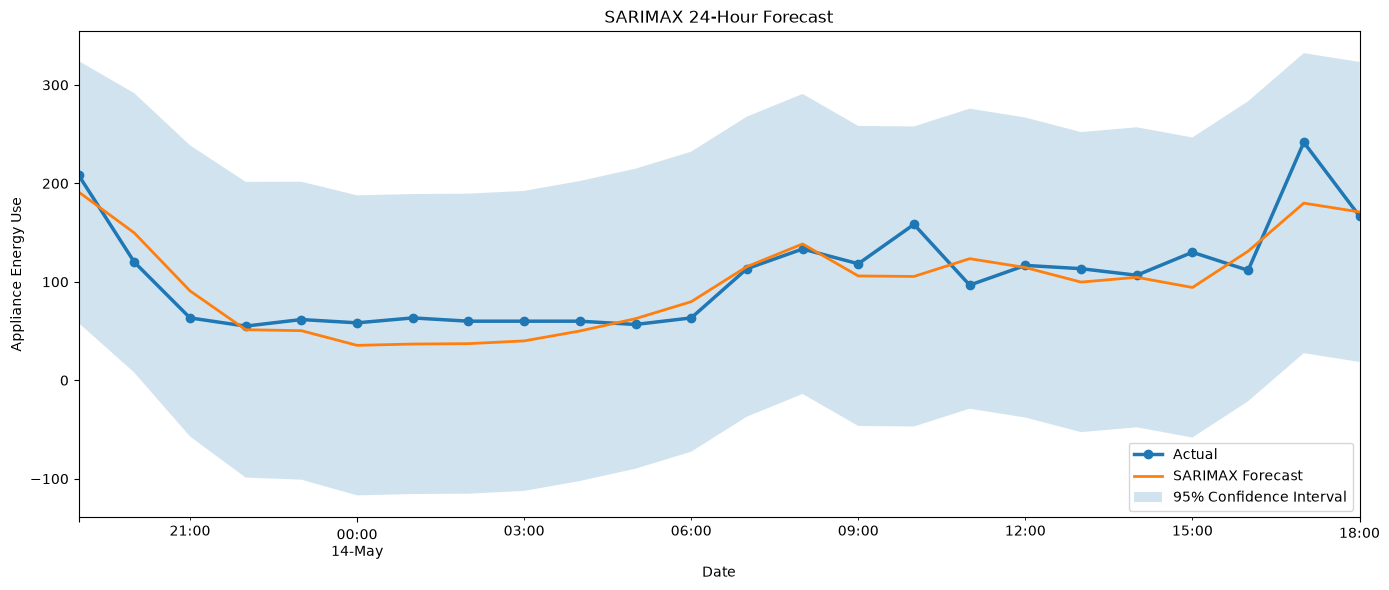

In [38]:
# plot  with confidence intervals

fig, ax = plt.subplots(figsize=(14, 6))

first_24_test.plot(
    ax=ax,
    label="Actual",
    marker="o",
    linewidth=2.5
)

sarimax_24_mean.plot(
    ax=ax,
    label="SARIMAX Forecast",
    linewidth=2
)

ax.fill_between(
    sarimax_24_ci.index,
    sarimax_24_ci.iloc[:, 0],
    sarimax_24_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

ax.set_title(
    "SARIMAX 24-Hour Forecast"
)

ax.set_xlabel("Date")
ax.set_ylabel("Appliance Energy Use")

ax.legend()

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "26_sarimax_24h_forecast.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# Calculate the required 24-hour metrics


def calculate_rmse(y_true, y_pred):
    """
    Calculate Root Mean Squared Error.
    """
    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


def calculate_mase(
    y_true,
    y_pred,
    y_train,
    seasonality=24
):
    """
    Calculate Mean Absolute Scaled Error using
    the in-sample seasonal naive error as scale.
    """

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    y_train = np.asarray(
        y_train,
        dtype=float
    )

    seasonal_errors = np.abs(
        y_train[seasonality:]
        - y_train[:-seasonality]
    )

    scale = seasonal_errors.mean()

    if scale == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                y_true - y_pred
            )
        )
        / scale
    )


sarimax_24_metrics = {
    "Model": "SARIMAX",
    
    "MAE": mean_absolute_error(
        first_24_test,
        sarimax_24_mean
    ),
    
    "RMSE": calculate_rmse(
        first_24_test,
        sarimax_24_mean
    ),
    
    "MASE": calculate_mase(
        first_24_test,
        sarimax_24_mean,
        train,
        seasonality=24
    ),
    
    "Bias": np.mean(
        sarimax_24_mean.values
        - first_24_test.values
    )
}

sarimax_24_metrics_df = pd.DataFrame(
    [sarimax_24_metrics]
)

sarimax_24_metrics_df.round(3)

,Model,MAE,RMSE,MASE,Bias
0,SARIMAX,18.841,24.158,0.353,-7.402


In [40]:
# Save the 24-hour SARIMAX forecast

sarimax_24_forecast_df = pd.DataFrame({
    "Actual": first_24_test,
    "SARIMAX": sarimax_24_mean,
    "Lower_95": sarimax_24_ci.iloc[:, 0],
    "Upper_95": sarimax_24_ci.iloc[:, 1]
})

sarimax_24_forecast_df.to_csv(
    FORECAST_DIR /
    "sarimax_24h_forecast.csv"
)

sarimax_24_metrics_df.to_csv(
    METRICS_DIR /
    "sarimax_24h_metrics.csv",
    index=False
)

print("SARIMAX 24-hour outputs saved successfully.")

SARIMAX 24-hour outputs saved successfully.


In [41]:
ljung_box_results.to_csv(
    METRICS_DIR /
    "sarimax_ljung_box_results.csv"
)

print("Ljung-Box results saved.")

Ljung-Box results saved.


## Rolling 24-Hour SARIMAX Evaluation

To evaluate SARIMAX consistently with the benchmark models, a rolling-origin evaluation is performed over the final 14 days.

At each forecast origin, all observations available up to that point are used to refit the selected SARIMAX specification and forecast the following 24 hours.

This generates 14 non-overlapping 24-hour forecasts covering the complete test period.

The SARIMAX specification remains fixed at the order selected by the AIC search, avoiding repeated hyperparameter optimisation during test evaluation.

In [42]:
def rolling_sarimax_forecast(
    y,
    X,
    initial_train_size,
    test_steps,
    horizon,
    order,
    seasonal_order
):
    """
    Perform rolling-origin SARIMAX forecasting.

    The selected SARIMAX specification is refitted
    at each 24-hour forecast origin.
    """

    predictions = []
    actual_values = []

    number_of_origins = (
        test_steps // horizon
    )

    for origin in range(number_of_origins):

        train_end = (
            initial_train_size
            + origin * horizon
        )

        forecast_end = (
            train_end
            + horizon
        )

        y_history = y.iloc[:train_end]

        y_actual = y.iloc[
            train_end:forecast_end
        ]

        X_history = X.iloc[:train_end]

        X_future = X.iloc[
            train_end:forecast_end
        ]

        print(
            f"Forecast origin "
            f"{origin + 1}/{number_of_origins}"
        )

        model = SARIMAX(
            y_history,
            exog=X_history,
            order=order,
            seasonal_order=seasonal_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(
            disp=False,
            maxiter=100
        )

        forecast = fitted_model.get_forecast(
            steps=len(y_actual),
            exog=X_future
        )

        forecast_mean = (
            forecast.predicted_mean
        )

        forecast_mean.index = (
            y_actual.index
        )

        predictions.append(
            forecast_mean
        )

        actual_values.append(
            y_actual
        )

    predictions = pd.concat(
        predictions
    )

    actual_values = pd.concat(
        actual_values
    )

    return (
        actual_values,
        predictions
    )

In [43]:
rolling_actual_sarimax, rolling_sarimax_pred = (
    rolling_sarimax_forecast(
        y=target,
        X=X,
        initial_train_size=INITIAL_TRAIN_SIZE,
        test_steps=TEST_STEPS,
        horizon=FORECAST_HORIZON,
        order=best_order,
        seasonal_order=best_seasonal_order
    )
)

print(
    "\nRolling SARIMAX predictions:",
    len(rolling_sarimax_pred)
)

print(
    "Actual observations:",
    len(rolling_actual_sarimax)
)

Forecast origin 1/14
Forecast origin 2/14
Forecast origin 3/14
Forecast origin 4/14
Forecast origin 5/14
Forecast origin 6/14
Forecast origin 7/14
Forecast origin 8/14
Forecast origin 9/14
Forecast origin 10/14
Forecast origin 12/14
Forecast origin 13/14
Forecast origin 14/14

Rolling SARIMAX predictions: 336
Actual observations: 336


In [44]:
rolling_sarimax_output = pd.DataFrame({
    "Actual": rolling_actual_sarimax,
    "SARIMAX": rolling_sarimax_pred
})

rolling_sarimax_output.to_csv(
    FORECAST_DIR /
    "sarimax_rolling_24h_forecast.csv"
)

print(
    "Rolling SARIMAX forecasts saved."
)

Rolling SARIMAX forecasts saved.


In [45]:
rolling_sarimax_metrics = {
    "Model": "SARIMAX",

    "MAE": mean_absolute_error(
        rolling_actual_sarimax,
        rolling_sarimax_pred
    ),

    "RMSE": calculate_rmse(
        rolling_actual_sarimax,
        rolling_sarimax_pred
    ),

    "MASE": calculate_mase(
        rolling_actual_sarimax,
        rolling_sarimax_pred,
        train,
        seasonality=24
    ),

    "Bias": np.mean(
        rolling_sarimax_pred.values
        - rolling_actual_sarimax.values
    )
}

rolling_sarimax_metrics_df = pd.DataFrame(
    [rolling_sarimax_metrics]
)

rolling_sarimax_metrics_df.round(3)

,Model,MAE,RMSE,MASE,Bias
0,SARIMAX,36.71,65.135,0.687,-9.081


In [46]:
rolling_sarimax_metrics_df.to_csv(
    METRICS_DIR /
    "sarimax_rolling_24h_metrics.csv",
    index=False
)

print(
    "Rolling SARIMAX metrics saved."
)

Rolling SARIMAX metrics saved.


In [47]:
# Calculate improvement over the strongest benchmark

benchmark_rmse = 74.906

sarimax_rmse = rolling_sarimax_metrics_df.loc[
    0,
    "RMSE"
]

sarimax_improvement = (
    (benchmark_rmse - sarimax_rmse)
    / benchmark_rmse
    * 100
)

print(
    "SARIMAX RMSE improvement over strongest benchmark:",
    round(sarimax_improvement, 2),
    "%"
)

SARIMAX RMSE improvement over strongest benchmark: 13.04 %
